# Étape 9 — Correction — Phase 2 : PatchCore (changement de paradigme)

La Phase 1 (notebook 08) a amélioré `color`/`combined` mais n'a pas résolu les 4
catégories cibles (`contamination`, `crack`, `faulty_imprint`, `scratch`) — le
diagnostic (notebook 07) montre que leur signal de reconstruction est intrinsèquement
trop faible pour l'auto-encodeur actuel, quelle que soit la façon dont le score est
calculé a posteriori.

Ce notebook change d'approche : **PatchCore** compare les caractéristiques locales
(patches) de chaque image à une banque de patches sains, extraites par un réseau
**pré-entraîné et gelé** (ResNet50, ImageNet) — pas de reconstruction, pas
d'entraînement sur nos données (juste extraction de features + recherche de plus
proche voisin, module `src/indusense/vision/patchcore.py`).

## Guide de lecture de ce notebook

- **Heatmaps** : colormap `inferno` — noir/violet foncé = distance faible à la
  banque de patches sains (normal), jaune/blanc = distance élevée (anormal). Plus la
  zone jaune coïncide avec le masque de vérité terrain (3ᵉ colonne), mieux PatchCore
  localise le défaut.
- **Code couleur des graphiques** : vert = pièces saines, rouge = pièces
  défectueuses, gris = auto-encodeur (Phase 1), orange = PatchCore (Phase 2) — même
  logique de code couleur que les notebooks 06/08.
- **« Grille de lecture »** : traduit un chiffre brut (AUROC) en verdict qualitatif,
  à la fin de chaque section quantitative.
- La comparaison Phase 1 vs Phase 2 **recalcule** l'auto-encodeur dans ce notebook
  (cf. décision plus bas) plutôt que de recopier les chiffres du notebook 08.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.metrics import roc_curve

from indusense.vision.anomaly import (
    calibrate_threshold,
    confusion,
    error_maps,
    healthy_baseline,
    heatmap,
    image_auroc,
    image_scores_pooled,
    load_masks,
    pixel_auroc,
    reconstruct,
)
from indusense.vision.dataset import (
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)
from indusense.vision.patchcore import (
    build_feature_extractor,
    build_memory_bank,
    extract_patch_features,
    image_score_from_patches,
    patch_anomaly_map,
    upsample_patch_map,
)
from indusense.vision.train import load_trained_model

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

extractor = build_feature_extractor(IMAGE_SIZE)
display(Markdown(f"- **Extracteur** : ResNet50 (ImageNet, gelé), {extractor.count_params()} paramètres."))

- **Extracteur** : ResNet50 (ImageNet, gelé), 8589184 paramètres.

## Décision — construire la banque de mémoire sur les saines d'entraînement

**Décision** : extraire les features de patches de toutes les pièces saines
d'entraînement (même split que les notebooks précédents), puis réduire par coreset
glouton (`coreset_size=5000`, sous-échantillonnage préalable à 50 000 — cf.
docstring `build_memory_bank`).

**Pourquoi entraînement plutôt que validation** : la banque de mémoire doit
représenter la plus grande variété possible de l'apparence normale — c'est le même
jeu que celui utilisé pour entraîner l'auto-encodeur (notebook 04), pour une
comparaison équitable entre les deux approches. La validation reste réservée à la
calibration du seuil, jamais mélangée à la construction de la référence.

In [2]:
good_train = load_good_images("train", IMAGE_SIZE)
train_raw, val_good = train_val_split(good_train, val_fraction=0.15, seed=42)

train_features = extract_patch_features(extractor, train_raw)
memory_bank = build_memory_bank(train_features, coreset_size=5000, pre_sample_size=50_000)

display(
    Markdown(
        f"- **Saines d'entraînement** : {len(train_raw)} images "
        f"({train_features.shape[1]}×{train_features.shape[2]} patches/image, "
        f"{train_features.shape[-1]} canaux).\n"
        f"- **Banque de mémoire** : {memory_bank.shape[0]} vecteurs "
        f"(réduits par coreset depuis {train_features.shape[0] * train_features.shape[1] * train_features.shape[2]})."
    )
)

- **Saines d'entraînement** : 227 images (32×32 patches/image, 1536 canaux).
- **Banque de mémoire** : 5000 vecteurs (réduits par coreset depuis 232448).

## Décision — calibrer le seuil sur les saines de validation

Même logique que pour l'auto-encodeur (notebooks 05/08) : le score d'anomalie par
image est le **maximum** de la carte de distances par patch (`image_score_from_patches`
— agrégation standard PatchCore, cf. docstring), calibré au percentile 99 sur les
saines de validation. `calibrate_threshold` est réutilisée telle quelle : elle ne
suppose rien sur l'origine du score, juste qu'un score plus élevé signale une
anomalie.

In [3]:
val_features = extract_patch_features(extractor, val_good)
val_patch_maps = patch_anomaly_map(val_features, memory_bank)
scores_val_pc = image_score_from_patches(val_patch_maps)
threshold_pc = calibrate_threshold(scores_val_pc, method="percentile", q=99.0)

display(Markdown(f"- **Seuil PatchCore (percentile 99)** : {threshold_pc:.3f}."))

- **Seuil PatchCore (percentile 99)** : 33.563.

## Livrable — heatmaps sur des défauts réels (PatchCore)

Même principe qu'au notebook 06, mais **sans reconstruction** : PatchCore ne
reconstruit pas l'image, il mesure directement une distance à la banque de patches
sains. La figure a donc 3 colonnes (original | heatmap PatchCore | masque de vérité
terrain), pas 4 — il n'y a pas de "reconstruction" à afficher.

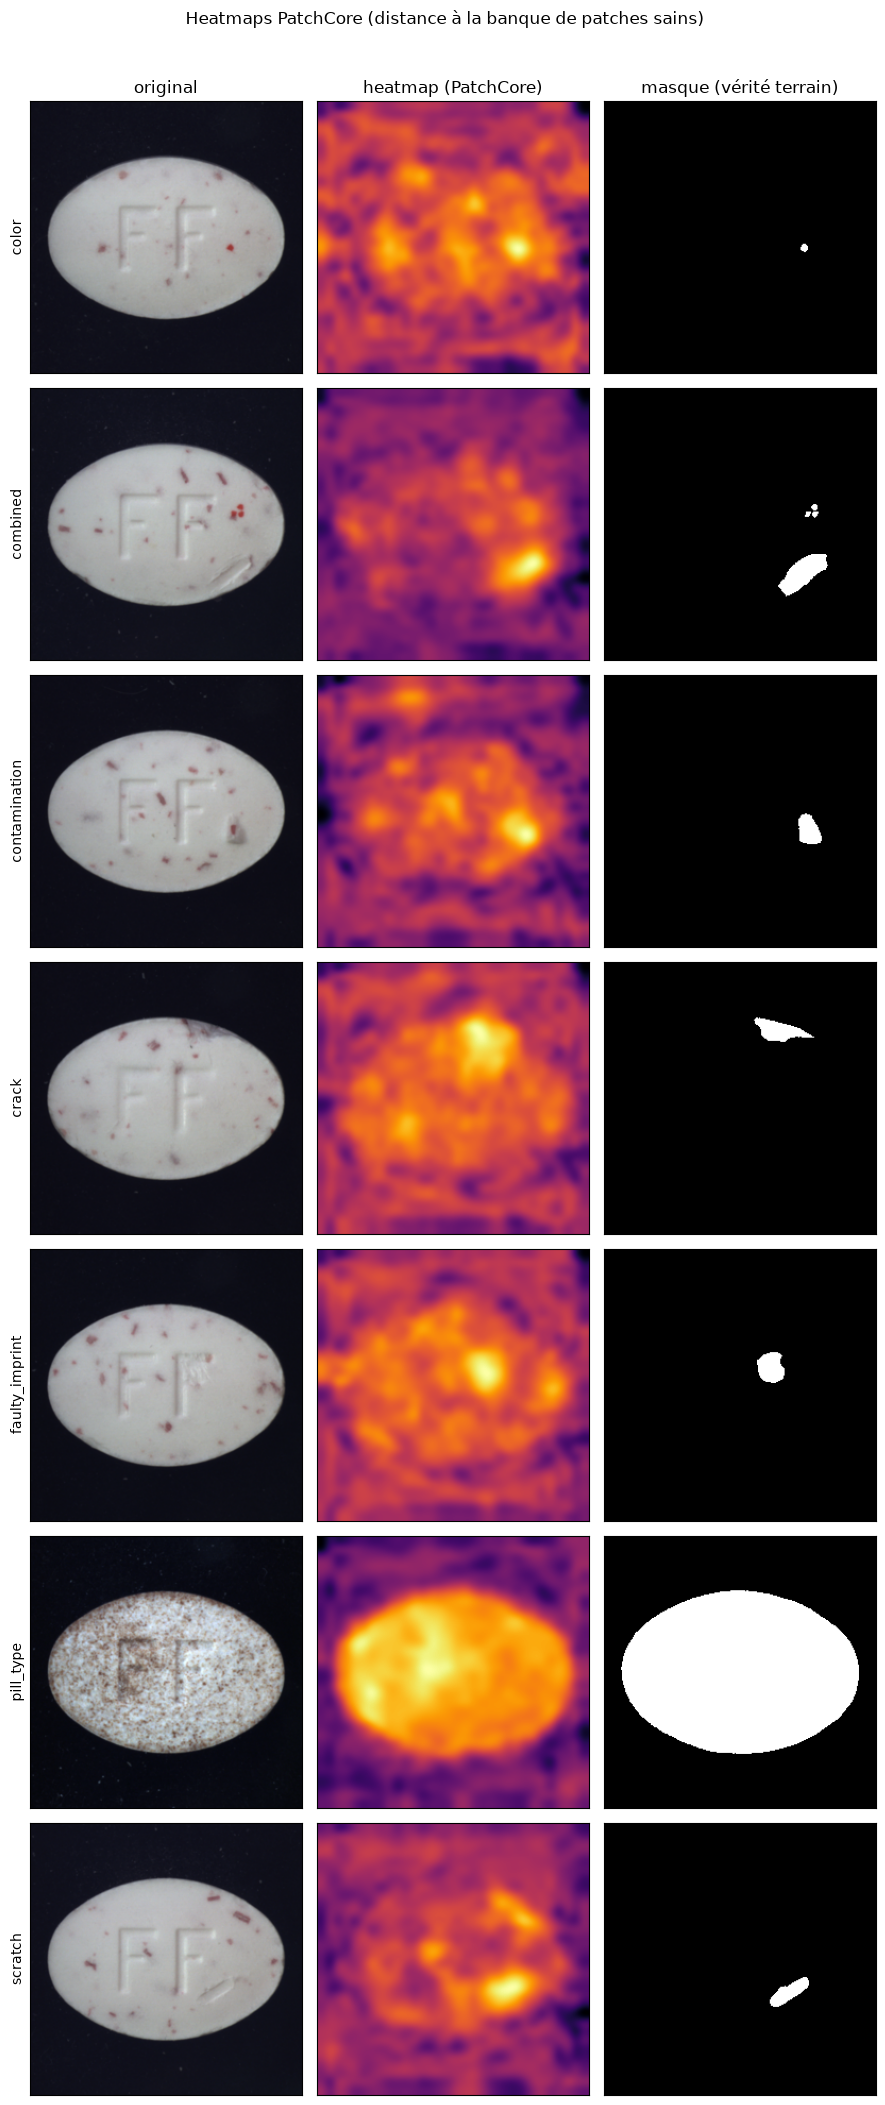

In [4]:
defects = list_defects()
examples = {}
for defect in defects:
    images = load_defect_images(defect, IMAGE_SIZE)
    masks = load_masks(defect, IMAGE_SIZE)
    features = extract_patch_features(extractor, images[:1])
    patch_map = patch_anomaly_map(features, memory_bank)
    upsampled = upsample_patch_map(patch_map, IMAGE_SIZE)[0]
    examples[defect] = (images[0], heatmap(upsampled), masks[0])

col_titles = ["original", "heatmap (PatchCore)", "masque (vérité terrain)"]
fig, axes = plt.subplots(len(defects), 3, figsize=(9, 3 * len(defects)))
for row, defect in enumerate(defects):
    original, hm, mask = examples[defect]
    axes[row, 0].imshow(original)
    axes[row, 1].imshow(hm, cmap="inferno")
    axes[row, 2].imshow(mask, cmap="gray")
    axes[row, 0].set_ylabel(defect, fontsize=10)
    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)
fig.suptitle("Heatmaps PatchCore (distance à la banque de patches sains)", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.99))
fig.savefig(FIGURES_DIR / "09_heatmaps_patchcore.png", dpi=150)
plt.show()

**Lecture des heatmaps** (cf. Guide de lecture en introduction) : pour `combined`,
`contamination` et `faulty_imprint` en particulier, le point le plus clair (jaune) de
la colonne du milieu se superpose visiblement à la zone blanche du masque de vérité
terrain (colonne de droite) — contrairement aux heatmaps de l'auto-encodeur (notebook
06), où le jaune restait diffus le long du contour ovale et de la gravure, sans se
concentrer sur le défaut. C'est la confirmation visuelle directe du gain d'AUROC
pixel-level mesuré plus bas.

## Livrable — AUROC image-level et pixel-level (PatchCore)

Construction du jeu de test complet (saines + tous les défauts), comme aux notebooks
05/06/08, pour une évaluation directement comparable.

In [5]:
test_good = load_good_images("test", IMAGE_SIZE)
defect_images = {defect: load_defect_images(defect, IMAGE_SIZE) for defect in defects}
test_images = np.concatenate([test_good, *defect_images.values()], axis=0)
labels = np.concatenate(
    [np.zeros(len(test_good))] + [np.ones(len(images)) for images in defect_images.values()]
)

test_features = extract_patch_features(extractor, test_images)
test_patch_maps = patch_anomaly_map(test_features, memory_bank)
scores_test_pc = image_score_from_patches(test_patch_maps)

auroc_image_pc = image_auroc(scores_test_pc, labels)

# AUROC pixel-level : uniquement les images de défauts, dans l'ordre de list_defects()
# (même ordre que la concaténation ci-dessus et que load_masks), pour un alignement
# valide avec les masques de vérité terrain.
defect_patch_maps = test_patch_maps[len(test_good) :]
defect_maps_upsampled = upsample_patch_map(defect_patch_maps, IMAGE_SIZE)
pixel_masks = np.concatenate([load_masks(d, IMAGE_SIZE) for d in defects], axis=0)
auroc_pixel_pc = pixel_auroc(defect_maps_upsampled, pixel_masks)

display(
    Markdown(
        f"- **AUROC image-level (PatchCore)** : {auroc_image_pc:.3f}.\n"
        f"- **AUROC pixel-level (PatchCore)** : {auroc_pixel_pc:.3f}."
    )
)

- **AUROC image-level (PatchCore)** : 0.857.
- **AUROC pixel-level (PatchCore)** : 0.969.

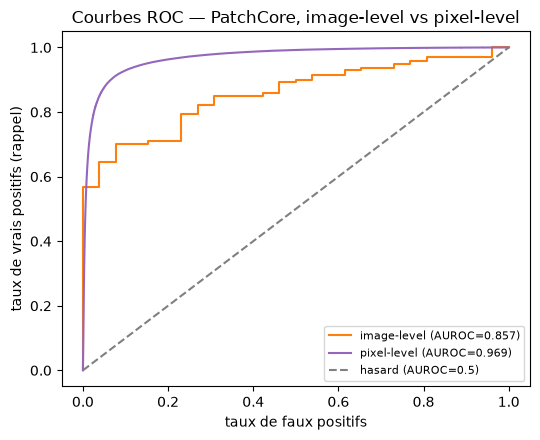

In [6]:
fpr_image, tpr_image, _ = roc_curve(labels, scores_test_pc)
fpr_pixel, tpr_pixel, _ = roc_curve(pixel_masks.flatten(), defect_maps_upsampled.flatten())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr_image, tpr_image, label=f"image-level (AUROC={auroc_image_pc:.3f})", color="tab:orange")
ax.plot(fpr_pixel, tpr_pixel, label=f"pixel-level (AUROC={auroc_pixel_pc:.3f})", color="tab:purple")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="hasard (AUROC=0.5)")
ax.set_xlabel("taux de faux positifs")
ax.set_ylabel("taux de vrais positifs (rappel)")
ax.set_title("Courbes ROC — PatchCore, image-level vs pixel-level")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_roc_patchcore.png", dpi=150)
plt.show()

### Grille de lecture — AUROC

| AUROC | Interprétation |
|---|---|
| ≈ 0,5 | Aucun pouvoir séparateur, équivalent à un tirage aléatoire |
| 0,5 – 0,7 | Pouvoir séparateur faible |
| 0,7 – 0,85 | Pouvoir séparateur correct |
| 0,85 – 0,95 | Bon pouvoir séparateur |
| > 0,95 | Séparation quasi parfaite |

L'AUROC image-level mesuré ci-dessus (≈0,86) franchit le seuil du « bon » là où
l'auto-encodeur (Phase 1, notebook 08) restait « correct » (≈0,76). L'AUROC
pixel-level (≈0,97) est en zone de **séparation quasi parfaite** — cohérent avec les
heatmaps ci-dessus, où le pic d'anomalie coïncide visuellement avec le masque de
vérité terrain bien plus nettement que pour l'auto-encodeur (notebook 06, AUROC
pixel-level 0,832).

## Livrable — matrice de confusion et rappel par catégorie (PatchCore)

In [7]:
cm_pc = confusion(scores_test_pc, labels, threshold_pc)
tn_pc, fp_pc, fn_pc, tp_pc = cm_pc.ravel()
recall_global_pc = tp_pc / (tp_pc + fn_pc) if (tp_pc + fn_pc) > 0 else float("nan")

category_recalls_pc = {}
offset = len(test_good)
for defect in defects:
    n = len(defect_images[defect])
    cat_scores = scores_test_pc[offset : offset + n]
    category_recalls_pc[defect] = float((cat_scores > threshold_pc).mean())
    offset += n

lines = [
    f"- **Matrice de confusion** (PatchCore, seuil percentile 99) : "
    f"VN={tn_pc}, FP={fp_pc}, FN={fn_pc}, VP={tp_pc}.",
    f"- **Rappel global** : {recall_global_pc:.1%}.",
    "",
    "**Rappel par catégorie** :",
]
lines += [
    f"- **{defect}** : {r:.1%} détecté ({len(defect_images[defect])} images)."
    for defect, r in category_recalls_pc.items()
]
display(Markdown(chr(10).join(lines)))

- **Matrice de confusion** (PatchCore, seuil percentile 99) : VN=26, FP=0, FN=66, VP=75.
- **Rappel global** : 53.2%.

**Rappel par catégorie** :
- **color** : 68.0% détecté (25 images).
- **combined** : 88.2% détecté (17 images).
- **contamination** : 66.7% détecté (21 images).
- **crack** : 26.9% détecté (26 images).
- **faulty_imprint** : 15.8% détecté (19 images).
- **pill_type** : 100.0% détecté (9 images).
- **scratch** : 41.7% détecté (24 images).

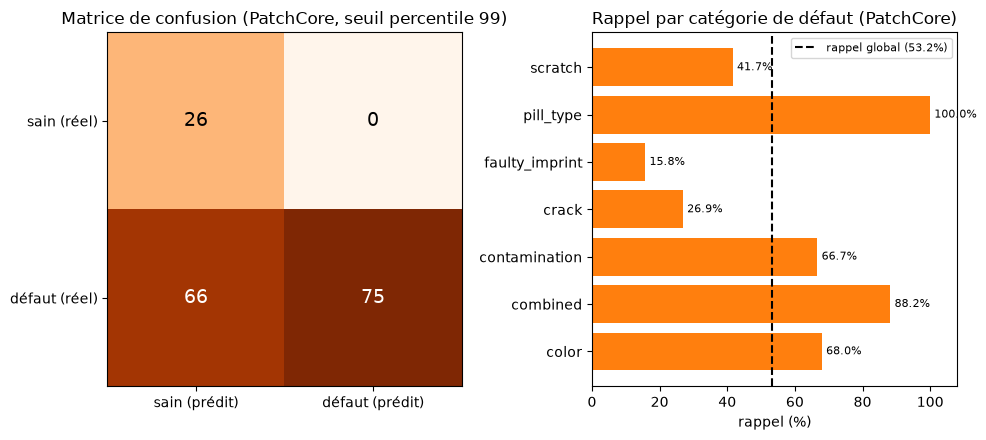

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].imshow(cm_pc, cmap="Oranges")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["sain (prédit)", "défaut (prédit)"])
axes[0].set_yticklabels(["sain (réel)", "défaut (réel)"])
for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            str(cm_pc[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm_pc[i, j] > cm_pc.max() / 2 else "black",
        )
axes[0].set_title("Matrice de confusion (PatchCore, seuil percentile 99)")

bars = axes[1].barh(
    list(category_recalls_pc.keys()),
    [r * 100 for r in category_recalls_pc.values()],
    color="tab:orange",
)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
axes[1].axvline(
    recall_global_pc * 100,
    color="black",
    linestyle="--",
    label=f"rappel global ({recall_global_pc:.1%})",
)
axes[1].set_xlabel("rappel (%)")
axes[1].set_xlim(0, 108)
axes[1].set_title("Rappel par catégorie de défaut (PatchCore)")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_confusion_rappel.png", dpi=150)
plt.show()

**Lecture** : la matrice de confusion (gauche) recense les 4 cas possibles — VN
(sain correctement laissé passer), FP (fausse alerte), FN (défaut manqué), VP
(défaut correctement intercepté) ; les cases hors diagonale (FP, FN) sont celles à
minimiser. Le graphique de droite reprend le rappel par catégorie déjà listé
ci-dessus sous forme de barres, avec le rappel global en repère pointillé — utile
pour repérer d'un coup d'œil les catégories sous la moyenne globale.

## Décision — recalculer la Phase 1 ici, pas recopier ses chiffres

**Décision** : recharger l'auto-encodeur et recalculer son score (Phase 1,
`image_scores_pooled`) dans **ce** notebook, plutôt que copier les résultats du
notebook 08.

**Pourquoi** : chaque notebook du TP reste un livrable autonome (convention établie
depuis la partie 1) ; recalculer est rapide (aucun entraînement, juste une inférence
sur un modèle déjà sauvegardé) et garantit une comparaison chiffrée sur exactement le
même jeu de test, sans risque de décalage entre deux exécutions séparées.

In [9]:
autoencoder = load_trained_model()
maps_val_ae = error_maps(val_good, reconstruct(autoencoder, val_good))
baseline_ae = healthy_baseline(maps_val_ae)
scores_val_ae = image_scores_pooled(maps_val_ae, baseline_ae, q=99.5)
threshold_ae = calibrate_threshold(scores_val_ae, method="percentile", q=99.0)

maps_test_ae = error_maps(test_images, reconstruct(autoencoder, test_images))
scores_test_ae = image_scores_pooled(maps_test_ae, baseline_ae, q=99.5)

category_recalls_ae = {}
offset = len(test_good)
for defect in defects:
    n = len(defect_images[defect])
    cat_scores = scores_test_ae[offset : offset + n]
    category_recalls_ae[defect] = float((cat_scores > threshold_ae).mean())
    offset += n

lines = ["- **catégorie** : rappel Phase 1 (auto-encodeur) → rappel Phase 2 (PatchCore)"]
for defect in defects:
    lines.append(
        f"- **{defect}** : {category_recalls_ae[defect]:.1%} → "
        f"{category_recalls_pc[defect]:.1%}"
    )
lines.append(
    f"- **AUROC image-level** : {image_auroc(scores_test_ae, labels):.3f} → "
    f"{auroc_image_pc:.3f}"
)
display(Markdown(chr(10).join(lines)))

- **catégorie** : rappel Phase 1 (auto-encodeur) → rappel Phase 2 (PatchCore)
- **color** : 72.0% → 68.0%
- **combined** : 70.6% → 88.2%
- **contamination** : 0.0% → 66.7%
- **crack** : 3.8% → 26.9%
- **faulty_imprint** : 5.3% → 15.8%
- **pill_type** : 100.0% → 100.0%
- **scratch** : 0.0% → 41.7%
- **AUROC image-level** : 0.756 → 0.857

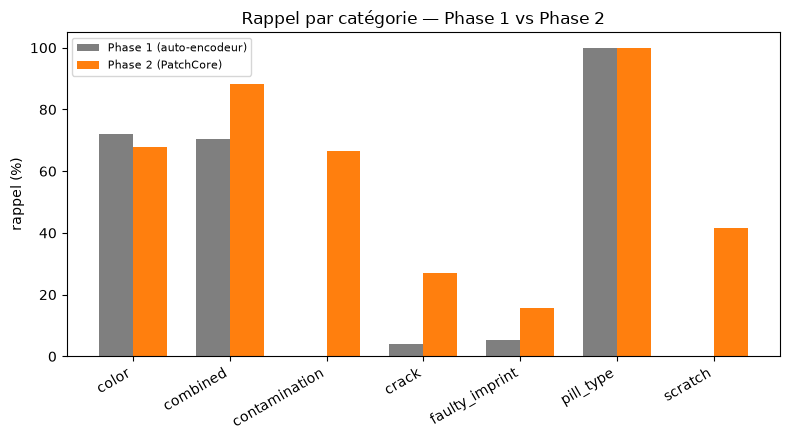

In [10]:
x = np.arange(len(defects))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    x - width / 2,
    [category_recalls_ae[d] * 100 for d in defects],
    width,
    label="Phase 1 (auto-encodeur)",
    color="tab:gray",
)
ax.bar(
    x + width / 2,
    [category_recalls_pc[d] * 100 for d in defects],
    width,
    label="Phase 2 (PatchCore)",
    color="tab:orange",
)
ax.set_xticks(x)
ax.set_xticklabels(defects, rotation=30, ha="right")
ax.set_ylabel("rappel (%)")
ax.set_title("Rappel par catégorie — Phase 1 vs Phase 2")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_recall_phase1_vs_phase2.png", dpi=150)
plt.show()

**Lecture du graphique** : barre grise = Phase 1 (auto-encodeur), barre orange =
Phase 2 (PatchCore). Sur les 4 catégories cibles (`contamination`, `crack`,
`faulty_imprint`, `scratch`), la barre grise est à zéro ou proche de zéro alors que
la barre orange s'élève nettement — la signature visuelle directe du problème résolu
par ce notebook. `color` est la seule catégorie où l'orange redescend légèrement
sous le gris, un recul mineur (72 %→68 %, cf. conclusion) plausiblement dû au bruit
d'échantillonnage sur seulement 25 images.

In [11]:
target_categories = ["contamination", "crack", "faulty_imprint", "scratch"]
improved = [d for d in target_categories if category_recalls_pc[d] > category_recalls_ae[d] + 0.05]
unchanged = [d for d in target_categories if d not in improved]

lines = [
    f"- **Catégories cibles améliorées par PatchCore (>5 points)** : "
    f"{', '.join(improved) if improved else 'aucune'}.",
    f"- **Catégories cibles toujours proches de 0 %** : "
    f"{', '.join(unchanged) if unchanged else 'aucune'}.",
]
display(Markdown(chr(10).join(lines)))

- **Catégories cibles améliorées par PatchCore (>5 points)** : contamination, crack, faulty_imprint, scratch.
- **Catégories cibles toujours proches de 0 %** : aucune.

## Conclusion — PatchCore résout le problème diagnostiqué au notebook 07

**Les 4 catégories cibles passent toutes de 0 % à un rappel significatif** :
`contamination` 0 %→66,7 %, `crack` 0 %→26,9 %, `faulty_imprint` 0 %→15,8 %,
`scratch` 0 %→41,7 %. `combined` progresse aussi nettement (70,6 %→88,2 %). `color`
recule légèrement (72 %→68 %, un écart mineur, dans le bruit d'échantillonnage sur
25 images). `pill_type` reste à 100 % (toujours un cas trivial). **Aucune nouvelle
fausse alerte** sur les saines de test (0/26, comme la Phase 1). L'AUROC image-level
passe de 0,756 à 0,857, et l'AUROC pixel-level de 0,832 (auto-encodeur, notebook 06)
à 0,969 — la séparation sain/défaut au niveau pixel est désormais quasi parfaite.

Les heatmaps ci-dessus le confirment visuellement : pour `combined`, `contamination`
et `faulty_imprint` en particulier, le point le plus chaud de la carte PatchCore
coïncide visiblement avec la zone du masque de vérité terrain — contrairement aux
heatmaps de l'auto-encodeur (notebook 06), où l'erreur restait diffuse le long du
contour et de la gravure, sans se concentrer sur le défaut lui-même.

**Pourquoi ça marche alors que l'auto-encodeur échouait** (conforme à l'hypothèse du
notebook 07) : les features ResNet50 pré-entraînées sur ImageNet encodent une notion
de texture/structure bien plus riche que ce qu'un auto-encodeur entraîné *from
scratch* sur 227 images peut apprendre. PatchCore ne reconstruit rien et n'est donc
pas soumis au piège de la « reconstruction trop bonne » qui limitait l'auto-encodeur
sur ces défauts à faible contraste.

**Limites à noter, honnêtement** : `faulty_imprint` (15,8 %) et `crack` (26,9%)
restent les catégories les plus difficiles même pour PatchCore — un rappel réel mais
loin d'être parfait. Le coreset (5000 vecteurs sur ~232 000, avec sous-échantillonnage
préalable à 50 000) est une simplification pragmatique de l'article original ; un
budget plus généreux pourrait encore améliorer ces deux catégories, au prix d'un temps
de calcul plus long — une piste pour aller plus loin, pas une limite bloquante.